In [31]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

%matplotlib widget


In [32]:
condition = "2mod_s126_no_trans"
checkpoint_epoch = 0
n_samples_test = 200
split = "test"
switch_epoch = 0
dataset = "biased_00"

In [33]:
experiment_name = get_experiment_name(condition, dataset, switch_epoch)
modules = get_setup_modules('syn', experiment_name)
global_workspace = get_global_workspace("syn", experiment_name, epoch=checkpoint_epoch, modules=modules)
data_module = get_data_module("syn",  experiment_name, modules=modules)

test_samples = get_data_samples(data_module, n_samples_test, split=split)
original_attr = test_samples[frozenset({ 'v_latents', 'attr'})]['attr']
original_v_latents = test_samples[frozenset({'v_latents', 'attr'})]['v_latents']
cat = original_attr[0]

domain_mods = global_workspace.domain_mods
gw_mod = global_workspace.gw_mod
latent_domains = global_workspace.encode_domains(test_samples)

Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/2mod_s126_no_trans_biased_00/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/2mod_s126_no_trans_biased_00/checkpoints/last.ckpt


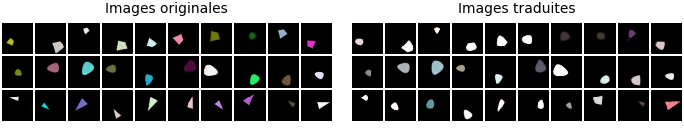

In [34]:
# demi cycle v_latents
domain_name_source = 'v_latents'
latents_source = latent_domains[frozenset({domain_name_source})]

z = gw_mod.encode(latents_source)[domain_name_source]
dcy = gw_mod.decode(z, domains={domain_name_source})

visual_module = cast(VisualLatentDomainModule, global_workspace.domain_mods["v_latents"])

decoded_images_dcy= visual_module.decode_images(dcy['v_latents'])
original_images_rgb = visual_module.decode_images(original_v_latents)

fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, cat, 10), get_n_per_category(decoded_images_dcy, cat, 10))
plt.show()


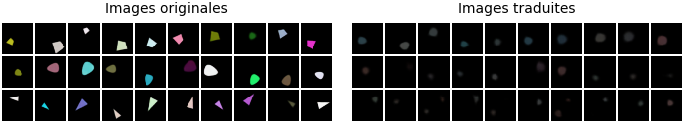

In [35]:
# translation_attr_to_v_latents
domain_name_source = 'attr'
domain_name_target = 'v_latents'
latents_source = latent_domains[frozenset({domain_name_source})]

z_spatial = gw_mod.encode(latents_source)[domain_name_source]
x_pred_spatial = gw_mod.decode(z_spatial, domains={domain_name_target})

decoded_images_tav= visual_module.decode_images(x_pred_spatial['v_latents'])
original_images_rgb = visual_module.decode_images(original_v_latents)

fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, cat, 10), get_n_per_category(decoded_images_tav, cat, 10))
plt.show()


In [36]:
# attribute to color to v_latents

# translation_attr_to_color
domain_name_source = 'attr'
domain_name_target = 'color'
latents_source = latent_domains[frozenset({domain_name_source})]

z_spatial = gw_mod.encode(latents_source)[domain_name_source]
x_pred_spatial = gw_mod.decode(z_spatial, domains={domain_name_target})

# translation_color_to_v_latents

domain_name_source = 'color'
domain_name_target = 'v_latents'

z_syn = gw_mod.encode(x_pred_spatial)[domain_name_source]
x_pred_syn = gw_mod.decode(z_syn, domains={domain_name_target})

vision3 = visual_module.decode_images(x_pred_syn['v_latents']*1.5)

fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, cat, 10), get_n_per_category(vision3, cat, 10), nrow=10)
plt.show()


KeyError: 'color'

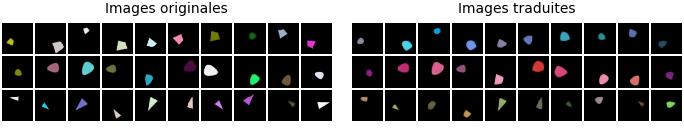

In [ ]:
# fusion: attribut to color to v_latent and attr to v_latents
z_fusion = 0.5*z_spatial + 0.5*z_syn
x_fusion = gw_mod.decode(z_fusion, domains={'v_latents'})
decoded_images_f= visual_module.decode_images(x_fusion['v_latents'])

fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, cat, 10), get_n_per_category(decoded_images_f, cat, 10), nrow=10)
plt.show()


In [ ]:
# est ce qu'on peut reconnaitre la catégorie avec seulement la couleur de l'espace latent attribut?
scaler = StandardScaler()
model = LogisticRegression(max_iter=1000)

colors_np = get_samples_rgb({"train_images": None, "images_decoded": decoded_images_f}, 'decoded_edge')

X = colors_np 
y = cat.argmax(dim=1).detach().cpu().numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(f"Précision globale (Accuracy) : {accuracy_score(y_test, y_pred):.2%}")
print("\nDétails par catégorie :")
print(classification_report(y_test, y_pred))

Précision globale (Accuracy) : 95.00%

Détails par catégorie :
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        13
           1       0.85      1.00      0.92        11
           2       1.00      1.00      1.00        16

    accuracy                           0.95        40
   macro avg       0.95      0.95      0.94        40
weighted avg       0.96      0.95      0.95        40



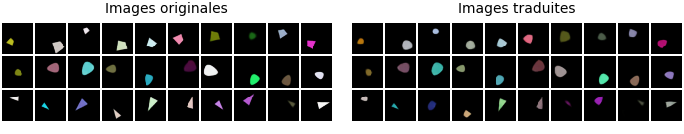

In [ ]:
# fustion: attr to v_latents + color to v_latents
p =0.5
latents_source = latent_domains[frozenset({'v_latents', 'attr', 'color'})]


gw_latents = gw_mod.encode(latents_source)
z = (1-p)*gw_latents['color'] + p*gw_latents['attr']

prediction = gw_mod.decode(z, domains={'v_latents'})['v_latents']
decoded_images_f= visual_module.decode_images(prediction)

fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, cat, 10), get_n_per_category(decoded_images_f, cat, 10))
plt.show()

In [ ]:
del original_images_rgb
del decoded_images_dcy
del decoded_images_tav
del decoded_images_f
del vision3
torch.cuda.empty_cache()